# LSTM-VAE Time Series Imputation (PyTorch)
This notebook is a sectioned version of `lstm_vae_imputation_torch.py`.

**Assumptions**
- `data.txt` exists in the current working directory.
- You have `numpy`, `pandas`, and `torch` installed.


In [1]:
# === Section: Imports ===
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:
# === Section: Load Data ===
# # Load data (assuming data.txt is downloaded and unzipped from Intel Lab repository)
# col_names = ['date','time','epoch','moteid','temperature','humidity','light','voltage']
# df = pd.read_csv('data.txt', sep=r'\s+', names=col_names, header=None)

# # Select one sensor (e.g., moteid=1) and sort by time
# sensor_id = 1
# df = df[df.moteid == sensor_id].sort_values(['date','time']).reset_index(drop=True)

# # Parse combined datetime and extract temperature series
# df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
# df = df.set_index('datetime')
# temperature_series = df['temperature'].astype(float)
# print("Loaded {} readings".format(len(temperature_series)))


Loaded 43047 readings


In [3]:
# New Dataset https://www.kaggle.com/datasets/olaflundstrom/sensor-data/code
DATASET = 'data/dataset1.csv'
df = pd.read_csv(DATASET)
df.sort_values('datetime', inplace=True)
df.set_index('datetime', inplace=True)
temperature_series = df['temperature'].astype(float)
print("Loaded dataset with shape:", df.shape)

Loaded dataset with shape: (26387, 2)


In [4]:
# === Section: Missingness + Outlier Masking ===
# Convert series to NumPy array
data = temperature_series.values
N = len(data)

# Choose missingness rate (e.g., 20%)
missing_rate = 0.3
np.random.seed(42)
mask = np.ones(N, dtype=bool)
missing_indices = np.random.choice(N, size=int(N * missing_rate), replace=False)
mask[missing_indices] = False

# Force missing values at the start and end
mask[:5] = False  # first 5 values missing
mask[-5:] = False  # last 5 values missing

# Mask outliers in addition to random missing values
# Using rolling 3-sigma (24-hour window) times 7 days for outlier detection
window = 24  # 24 hours times 7 days, assuming hourly data
rolling_mean = pd.Series(data, index=df.index).rolling(window=window, min_periods=1, center=True).mean().values
rolling_std = pd.Series(data, index=df.index).rolling(window=window, min_periods=1, center=True).std().values
outlier_threshold = 3
outlier_mask = np.abs(data - rolling_mean) > (outlier_threshold * rolling_std)

# Combine with existing mask (missing or outlier)
mask = mask & (~outlier_mask)

# Create observed series with NaNs for missing entries
observed = data.copy()
observed[~mask] = 0.0   # fill missing and outliers with 0 (or any placeholder)


In [5]:
# === Section: Prepare Model Inputs ===

# Prepare input for model: shape (seq_len, 1) for value and (seq_len, 1) for mask
input_values = torch.tensor(observed, dtype=torch.float32).unsqueeze(1)  # shape [N,1]
input_mask   = torch.tensor(mask.astype(float), dtype=torch.float32).unsqueeze(1)  # shape [N,1]
# Concatenate to shape [N, 2]
model_input  = torch.cat([input_values, input_mask], dim=1)


In [7]:
# === Section: Mini-batch Window Dataset (for SGD) ===

# Training on one full sequence (batch=1) works, but mini-batching on sliding windows is
# usually more stable and efficient for LSTM-VAEs.

from torch.utils.data import Dataset, DataLoader

# Windowing hyperparameters
seq_len = 48      # try 48, 96, 168 depending on sampling rate
stride = 1        # stride=1 gives many overlapping windows; increase to speed up
batch_size = 32

class WindowDataset(Dataset):
    def __init__(self, x_seq, y_seq, m_seq, seq_len, stride):
        # x_seq: [N, 2], y_seq: [N, 1], m_seq: [N, 1]
        self.x_seq = x_seq
        self.y_seq = y_seq
        self.m_seq = m_seq
        self.seq_len = int(seq_len)
        self.stride = int(stride)
        self.starts = list(range(0, len(x_seq) - self.seq_len + 1, self.stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = self.starts[idx]
        e = s + self.seq_len
        return self.x_seq[s:e], self.y_seq[s:e], self.m_seq[s:e]

# Build full tensors (kept for evaluation too)
x_full = model_input  # [N, 2]
y_full = torch.tensor(data, dtype=torch.float32).unsqueeze(-1)  # [N, 1]
m_full = torch.tensor(mask.astype(float), dtype=torch.float32).unsqueeze(-1)  # [N, 1]

train_ds = WindowDataset(x_full, y_full, m_full, seq_len=seq_len, stride=stride)
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=torch.cuda.is_available(),
)


In [9]:
# === Section: Model Definition (LSTM-VAE) ===

class LSTMVAE(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, latent_dim=16, num_layers=1): # testing with 1 layers
        """
        LSTM Variational Autoencoder for time series imputation.
        Args:
            input_dim (int): Number of input features (e.g., 2 for value and mask).
            hidden_dim (int): Number of LSTM hidden units.
            latent_dim (int): Dimensionality of the latent space.
            num_layers (int): Number of LSTM layers.
        """
        super().__init__()
        # Encoder LSTM
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Latent space
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Decoder initialization
        self.fc_decode = nn.Linear(latent_dim, hidden_dim)
        # Decoder LSTM and output layer
        self.decoder_lstm = nn.LSTM(1, hidden_dim, num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, 1)  # reconstruct single value

    def encode(self, x):
        # x: [batch, seq_len, input_dim]
        _, (h_n, _) = self.encoder_lstm(x)
        h = h_n[-1]  # take last layer's hidden state
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, seq_len):
        num_layers = self.decoder_lstm.num_layers
        batch_size = z.size(0)
        hidden_dim = self.decoder_lstm.hidden_size
        # Prepare latent to hidden and initial input
        h_dec_single = torch.tanh(self.fc_decode(z)).unsqueeze(0)  # [1, batch, hidden_dim]
        h_dec = h_dec_single.repeat(num_layers, 1, 1)  # [num_layers, batch, hidden_dim]
        c_dec = torch.zeros_like(h_dec)
        inp = torch.zeros(batch_size, seq_len, 1).to(z.device)
        dec_out, _ = self.decoder_lstm(inp, (h_dec, c_dec))
        recon = self.fc_out(dec_out).squeeze(-1)  # [batch, seq_len]
        return recon

    def forward(self, x):
        # x: [batch, seq_len, 2]
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        seq_len = x.size(1)
        recon_seq = self.decode(z, seq_len)
        # Ensure output shape is [batch, seq_len, 1] for consistency
        return recon_seq.unsqueeze(-1), mu, logvar


In [10]:
# === Section: Loss Function ===

# Define loss function
def vae_loss(recon_x, x_true, mask, mu, logvar):
    # Ensure all tensors are the same shape
    if recon_x.shape != x_true.shape:
        recon_x = recon_x.view_as(x_true)
    # Compute reconstruction loss (MSE) only on observed data
    mse = ((recon_x - x_true) ** 2)
    eps = 1e-8
    mse = (mse * mask).sum() / (mask.sum() + eps)  # average over observed points
    # KL Divergence between q(z|x) and N(0,I)
    batch_size = mu.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
    return mse + kld


In [11]:
# === Section: Training Setup ===

# Device handling
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model
model = LSTMVAE(input_dim=2, hidden_dim=64, latent_dim=16).to(device)

# Optimizer: AdamW is often a strong default for (LSTM) VAEs
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Scheduler: reduce LR when loss plateaus
# NOTE: some Torch builds don’t support the `verbose=` arg here.

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    threshold=1e-4,
    min_lr=1e-5,
)

# Gradient clipping helps prevent exploding gradients in LSTMs
grad_clip_max_norm = 1.0

# Full-sequence tensors for evaluation (kept on device)
x_eval = x_full.unsqueeze(0).to(device)  # [1, N, 2]
y_eval = y_full.unsqueeze(0).to(device)  # [1, N, 1]
m_eval = m_full.unsqueeze(0).to(device)  # [1, N, 1]


In [12]:
# === Section: Train (Mini-batch SGD via AdamW) ===

epochs = 100  # with mini-batches you often need fewer epochs than full-batch

# Track training dynamics for plotting
loss_history = []
lr_history = []

model.train()

for epoch in range(epochs):
    running_loss = 0.0
    num_batches = 0
    for x_batch, y_batch, m_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        m_batch = m_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        recon_seq, mu, logvar = model(x_batch)
        loss = vae_loss(recon_seq, y_batch, m_batch, mu, logvar)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_max_norm)
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1

    epoch_loss = running_loss / max(num_batches, 1)
    scheduler.step(epoch_loss)

    # record learning rate and loss for plotting
    lr = optimizer.param_groups[0]['lr']
    loss_history.append(epoch_loss)
    lr_history.append(lr)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d} | loss={epoch_loss:.4f} | lr={lr:.2e}")


Epoch 005 | loss=16.6719 | lr=1.00e-03
Epoch 010 | loss=13.7710 | lr=1.00e-03
Epoch 015 | loss=12.8574 | lr=1.00e-03
Epoch 020 | loss=10.8582 | lr=1.00e-03
Epoch 025 | loss=9.5704 | lr=1.00e-03
Epoch 030 | loss=9.6006 | lr=1.00e-03
Epoch 035 | loss=9.3394 | lr=5.00e-04
Epoch 040 | loss=7.8481 | lr=5.00e-04
Epoch 045 | loss=7.5822 | lr=5.00e-04
Epoch 050 | loss=7.4059 | lr=5.00e-04
Epoch 055 | loss=7.2606 | lr=5.00e-04
Epoch 060 | loss=7.0971 | lr=5.00e-04
Epoch 065 | loss=6.9209 | lr=5.00e-04
Epoch 070 | loss=6.8604 | lr=5.00e-04
Epoch 075 | loss=6.9549 | lr=5.00e-04
Epoch 080 | loss=6.8520 | lr=5.00e-04
Epoch 085 | loss=6.9429 | lr=5.00e-04
Epoch 090 | loss=6.7948 | lr=5.00e-04
Epoch 095 | loss=6.7267 | lr=5.00e-04
Epoch 100 | loss=6.7545 | lr=2.50e-04


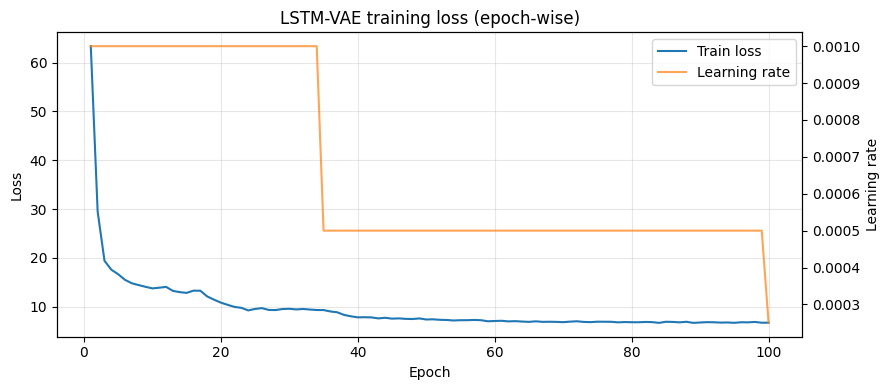

In [13]:
# === Section: Plot Training Loss Curve ===

# Run training first to populate loss_history/lr_history.
try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError("matplotlib is required for plotting. Install with: pip install matplotlib") from e

if 'loss_history' not in globals() or len(loss_history) == 0:
    raise RuntimeError("No loss_history found. Run the training cell first.")

epochs_ran = len(loss_history)
x = list(range(1, epochs_ran + 1))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(x, loss_history, label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Optional: plot LR on a secondary axis if available
if 'lr_history' in globals() and len(lr_history) == epochs_ran:
    ax2 = ax1.twinx()
    ax2.plot(x, lr_history, color='tab:orange', alpha=0.7, label='Learning rate')
    ax2.set_ylabel('Learning rate')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
else:
    ax1.legend(loc='best')

ax1.set_title('LSTM-VAE training loss (epoch-wise)')
plt.tight_layout()
plt.show()


In [14]:
# === Section: Evaluate Imputation (Windowed Reconstruction) ===

# Reconstructing the entire sequence in one forward pass can be heavy for long series.
# Instead, run the model on sliding windows and stitch predictions together by averaging
# overlapping window outputs.

from torch.utils.data import DataLoader

eval_stride = 1  # keep 1 for full coverage; increase for faster but sparser coverage
eval_ds = WindowDataset(x_full, y_full, m_full, seq_len=seq_len, stride=eval_stride)
eval_loader = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=torch.cuda.is_available(),
)

model.eval()
recon_sum = np.zeros(N, dtype=np.float64)
recon_count = np.zeros(N, dtype=np.float64)

with torch.no_grad():
    # iterate windows in the same order as eval_ds.starts
    starts = eval_ds.starts
    base = 0
    for x_batch, _, _ in eval_loader:
        bsz = x_batch.shape[0]
        x_batch = x_batch.to(device)
        recon_batch, _, _ = model(x_batch)  # [B, seq_len, 1]
        recon_batch = recon_batch.squeeze(-1).cpu().numpy()  # [B, seq_len]

        for i in range(bsz):
            s = starts[base + i]
            e = s + seq_len
            recon_sum[s:e] += recon_batch[i]
            recon_count[s:e] += 1.0

        base += bsz

# Average overlapping reconstructions
eps = 1e-12
recon = (recon_sum / (recon_count + eps)).astype(np.float32)

# If any points weren’t covered (can happen if eval_stride > 1), fall back to 0.0
recon[recon_count == 0] = 0.0

# Compute metrics only on missing positions
true_vals = data[~mask]
imputed_vals = recon[~mask]
mae = np.mean(np.abs(imputed_vals - true_vals))
rmse = np.sqrt(np.mean((imputed_vals - true_vals) ** 2))
print(f"Imputation MAE: {mae:.4f}, RMSE: {rmse:.4f}")


Imputation MAE: 0.8217, RMSE: 1.3110


In [15]:
# === Section: Save Model ===

# Save model and optimizer state
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, 'lstm_vae_model.pth')
